In [36]:
library(data.table)
library(ggplot2)

In [2]:
meta = fread("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/metadata.txt.gz")

In [19]:
sample2stage <- c(
'SLX-21143_SITTA2_HTJH3DSX2' = 'E8.5',
'SLX-21143_SITTA4_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTB2_HTJH3DSX2' = 'E8.5',
'SLX-21143_SITTB4_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTC4_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTD4_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTD5_HTJH3DSX2' = 'E7.5',
'SLX-21143_SITTE3_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTE5_HTJH3DSX2' = 'E7.5',
'SLX-21143_SITTF3_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTF5_HTJH3DSX2' = 'E7.5',
'SLX-21143_SITTG1_HTJH3DSX2' = 'E8.5',
'SLX-21143_SITTG3_HTJH3DSX2' = 'E9.5',
'SLX-21143_SITTG5_HTJH3DSX2' = 'E7.5',
'SLX-21143_SITTH1_HTJH3DSX2' = 'E8.5',
'SLX-21143_SITTH3_HTJH3DSX2' = 'E9.5'
)

sample2tomato = c(
'SLX-21143_SITTA2_HTJH3DSX2' = TRUE,
'SLX-21143_SITTA4_HTJH3DSX2' = TRUE,
'SLX-21143_SITTB2_HTJH3DSX2' = FALSE,
'SLX-21143_SITTB4_HTJH3DSX2' = FALSE,
'SLX-21143_SITTC4_HTJH3DSX2' = TRUE,
'SLX-21143_SITTD4_HTJH3DSX2' = FALSE,
'SLX-21143_SITTD5_HTJH3DSX2' = TRUE,
'SLX-21143_SITTE3_HTJH3DSX2' = TRUE,
'SLX-21143_SITTE5_HTJH3DSX2' = FALSE,
'SLX-21143_SITTF3_HTJH3DSX2' = FALSE,
'SLX-21143_SITTF5_HTJH3DSX2' = TRUE,
'SLX-21143_SITTG1_HTJH3DSX2' = TRUE,
'SLX-21143_SITTG3_HTJH3DSX2' = TRUE,
'SLX-21143_SITTG5_HTJH3DSX2' = FALSE,
'SLX-21143_SITTH1_HTJH3DSX2' = FALSE,
'SLX-21143_SITTH3_HTJH3DSX2' = FALSE
)

In [21]:
stages = data.frame(sample = names(sample2stage), stage = sample2stage)
tdTom = data.frame(sample = names(sample2stage), tdTom = sample2tomato)

add_meta = merge(stages, tdTom, by= 'sample')

In [23]:
meta = merge(meta, add_meta, by='sample')

In [28]:
test = fread("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz")

In [32]:
summary(test[doublet_call==FALSE,]$pass_rnaQC)

   Mode    TRUE 
logical   46263 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



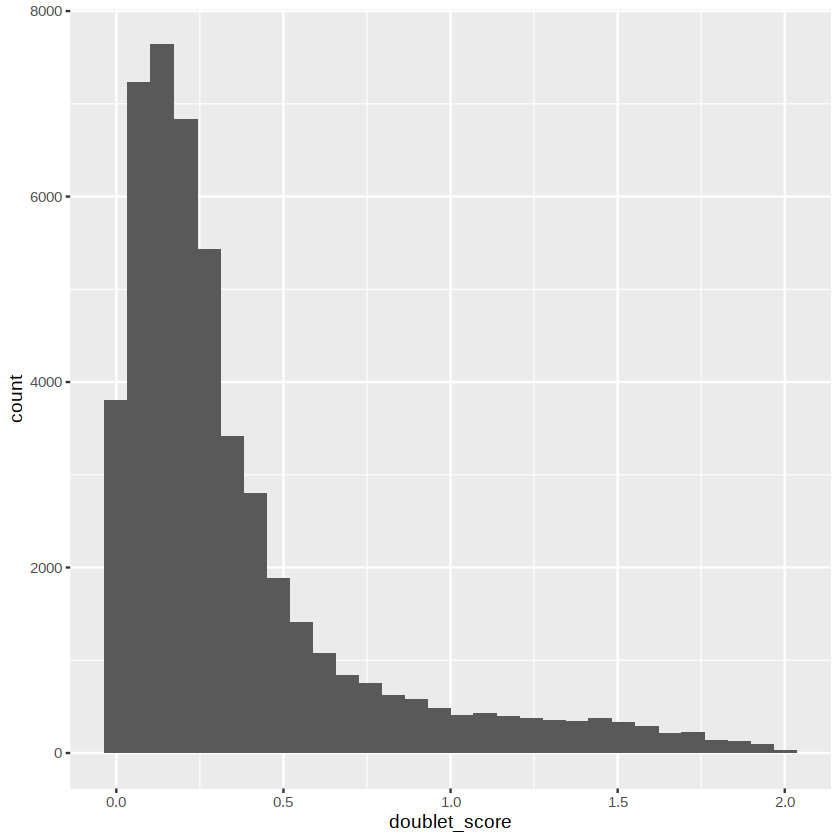

In [37]:
ggplot(test[pass_rnaQC==TRUE,], aes(doublet_score)) + geom_histogram()

In [56]:
nrow(test[doublet_score< 1.15 & pass_rnaQC==TRUE,])

[1] 47484

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



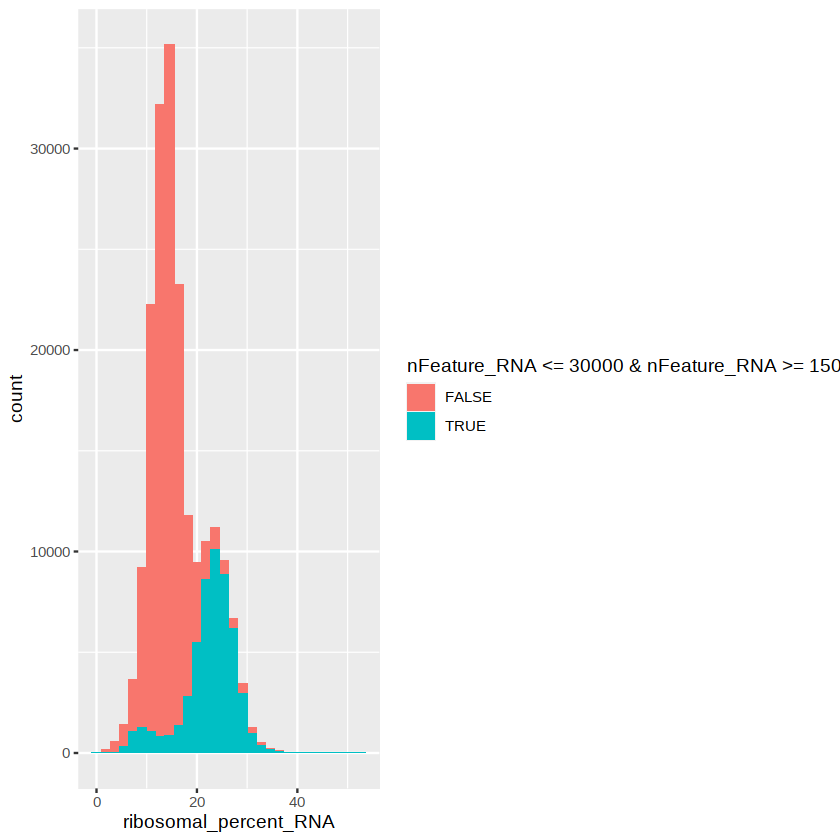

In [74]:
ggplot(test, aes(ribosomal_percent_RNA, fill=nFeature_RNA<=30000 & nFeature_RNA>=1500)) + geom_histogram()

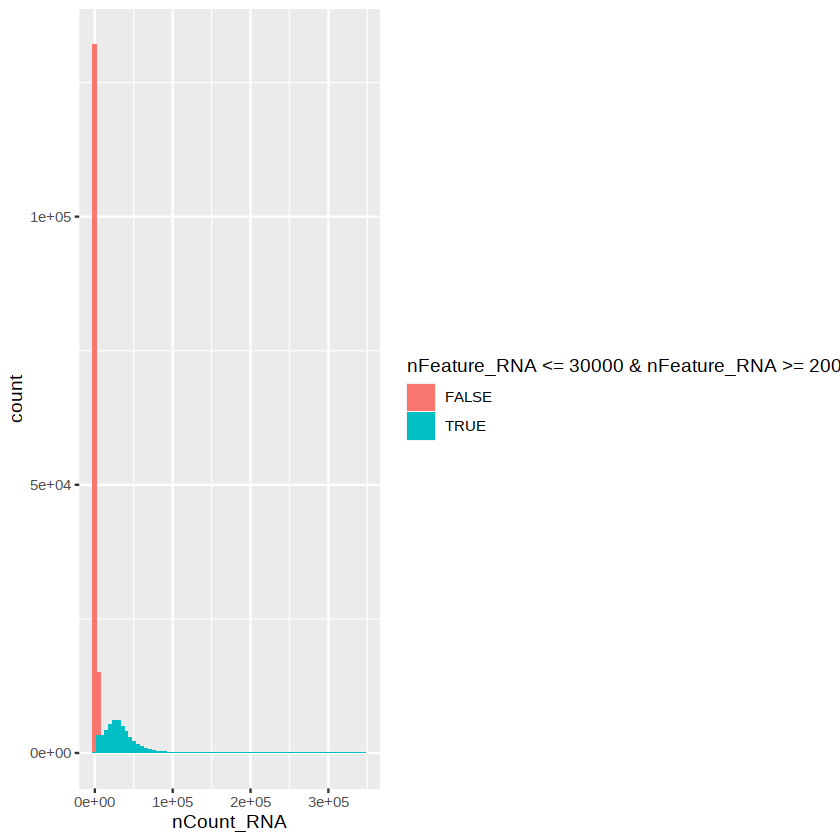

In [80]:
ggplot(test, aes(nCount_RNA, fill=nFeature_RNA<=30000 & nFeature_RNA>=2000)) + geom_histogram(bins = 70)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



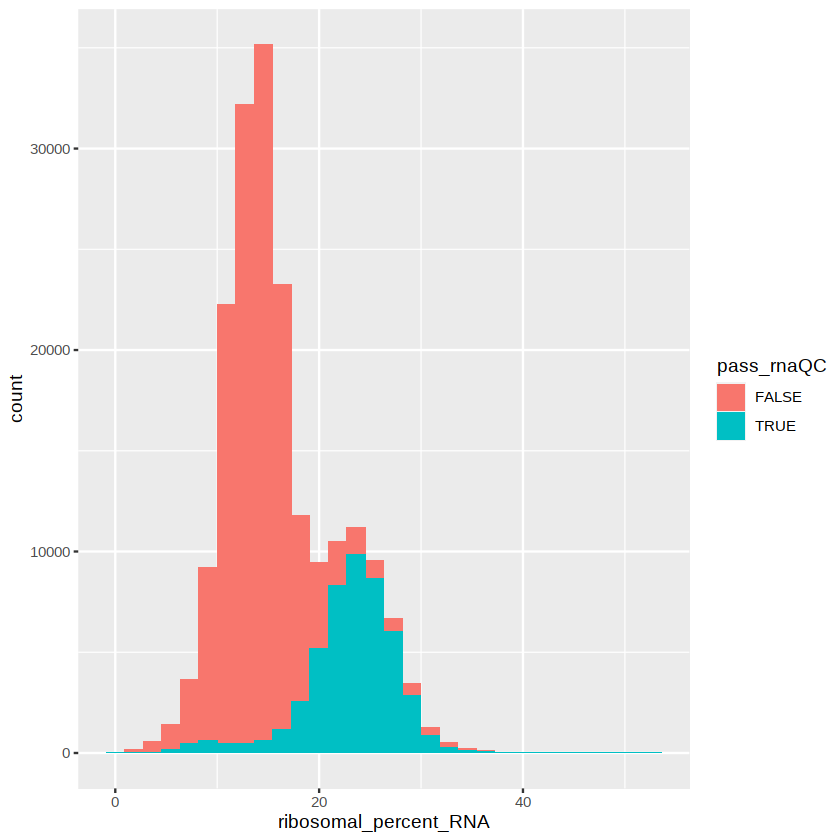

In [76]:
ggplot(test, aes(ribosomal_percent_RNA, fill=pass_rnaQC)) + geom_histogram()

In [61]:
nrow(test[mitochondrial_percent_RNA<=20 & ribosomal_percent_RNA<40])

[1] 185824

In [47]:
head(test[order(-doublet_score)])

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,pass_rnaQC,doublet_score,doublet_call
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<lgl>
SLX-21143_SITTC4_HTJH3DSX2#CATACCCGTATCGAAA-1,CATACCCGTATCGAAA-1,SLX-21143_SITTC4_HTJH3DSX2,9539,123356,1.55,20.31,SLX-21143,TRUE,2.00,TRUE
SLX-21143_SITTE3_HTJH3DSX2#CAGCGTGAGCTTAAGA-1,CAGCGTGAGCTTAAGA-1,SLX-21143_SITTE3_HTJH3DSX2,9938,186442,2.79,25.86,SLX-21143,TRUE,1.99,TRUE
SLX-21143_SITTE3_HTJH3DSX2#TGTTGGATCCCTCTAG-1,TGTTGGATCCCTCTAG-1,SLX-21143_SITTE3_HTJH3DSX2,9908,170496,2.28,23.47,SLX-21143,TRUE,1.99,TRUE
SLX-21143_SITTF3_HTJH3DSX2#TCTCCGACAGGGTTGA-1,TCTCCGACAGGGTTGA-1,SLX-21143_SITTF3_HTJH3DSX2,8614,88564,1.28,21.09,SLX-21143,TRUE,1.99,TRUE
SLX-21143_SITTG1_HTJH3DSX2#GCCGTGAGTACTGGGA-1,GCCGTGAGTACTGGGA-1,SLX-21143_SITTG1_HTJH3DSX2,8480,105867,0.40,28.31,SLX-21143,TRUE,1.99,TRUE
SLX-21143_SITTG3_HTJH3DSX2#AGTGATCAGGTCCTGC-1,AGTGATCAGGTCCTGC-1,SLX-21143_SITTG3_HTJH3DSX2,8862,120285,1.36,22.71,SLX-21143,TRUE,1.99,TRUE


In [81]:
meta = fread("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/metadata.txt.gz")

In [82]:
head(meta)

sample,cell,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,AAACCCAAGATGTTCC-1,4837,53199,1.47,22.87,E8.5,TRUE
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGCACTTTG-1,AAACCCAAGCACTTTG-1,310,648,32.25,12.81,E8.5,TRUE
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,AAACCCATCAGACCTA-1,4973,24165,0.95,19.26,E8.5,TRUE
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACGAAAGCGCCTTG-1,AAACGAAAGCGCCTTG-1,1614,4156,6.74,28.20,E8.5,TRUE
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACGAACAATGTTGC-1,AAACGAACAATGTTGC-1,5585,34341,0.22,26.76,E8.5,TRUE
SLX-21143_SITTA2_HTJH3DSX2,SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1,AAACGAACACACCAGC-1,5016,41496,1.66,25.01,E8.5,TRUE


In [85]:
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

## START TEST ##
args = list()
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$samples <- opts$samples
args$celltype_label <- "celltype.mapped_mnn"
#args$outdir <- file.path(io$basedir,"results_new/rna/celltype_proportions")
## END TEST ##

##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_rnaQC==TRUE & sample%in%args$samples & !is.na(eval(as.name(args$celltype_label)))] %>%
  setnames(args$celltype_label,"celltype")

# if (!"stage"%in%colnames(sample_metadata)) {
#   sample_metadata[,stage:=stringr::str_replace_all(sample,opts$sample2stage)]
# }
sample_metadata[,stage:=stringr::str_replace_all(sample,opts$sample2stage)]

table(sample_metadata$stage)


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code




 E7.5  E8.5  E9.5 
 5689 13080 26901 

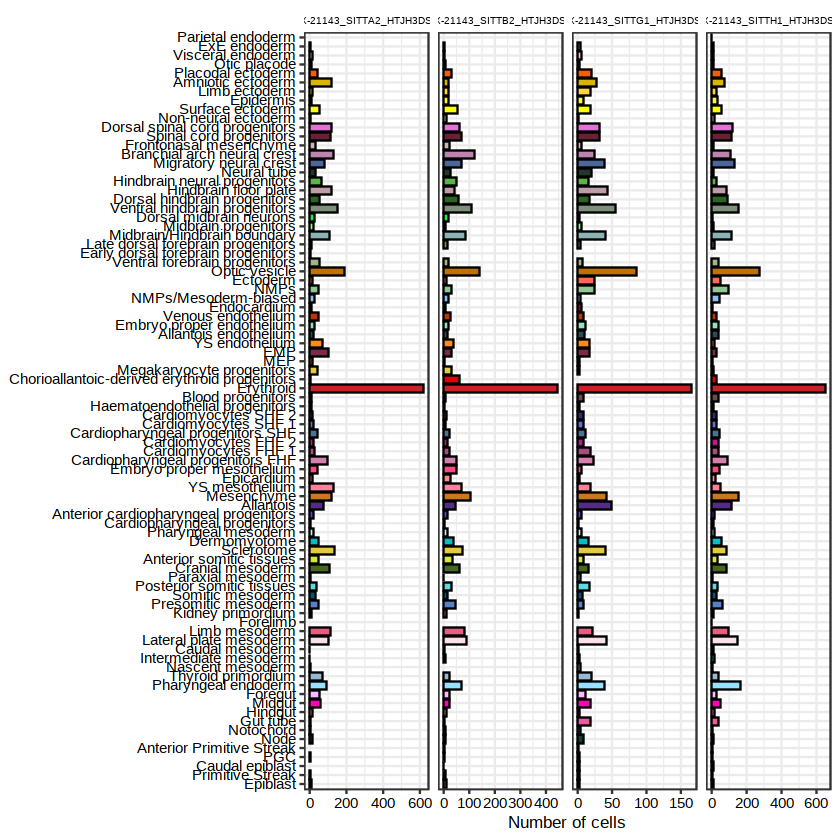

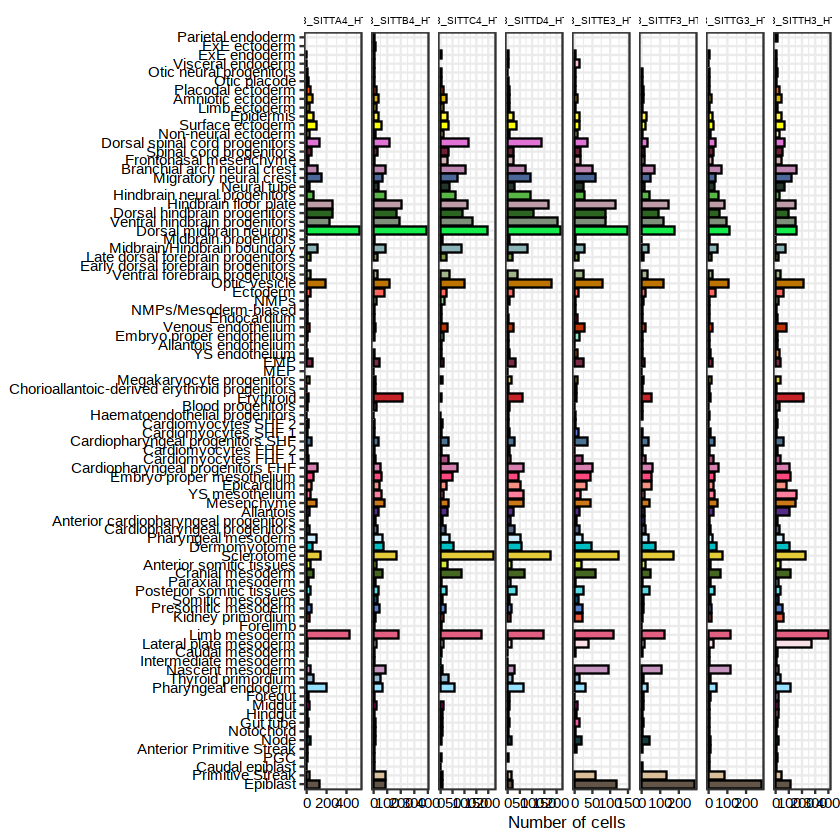

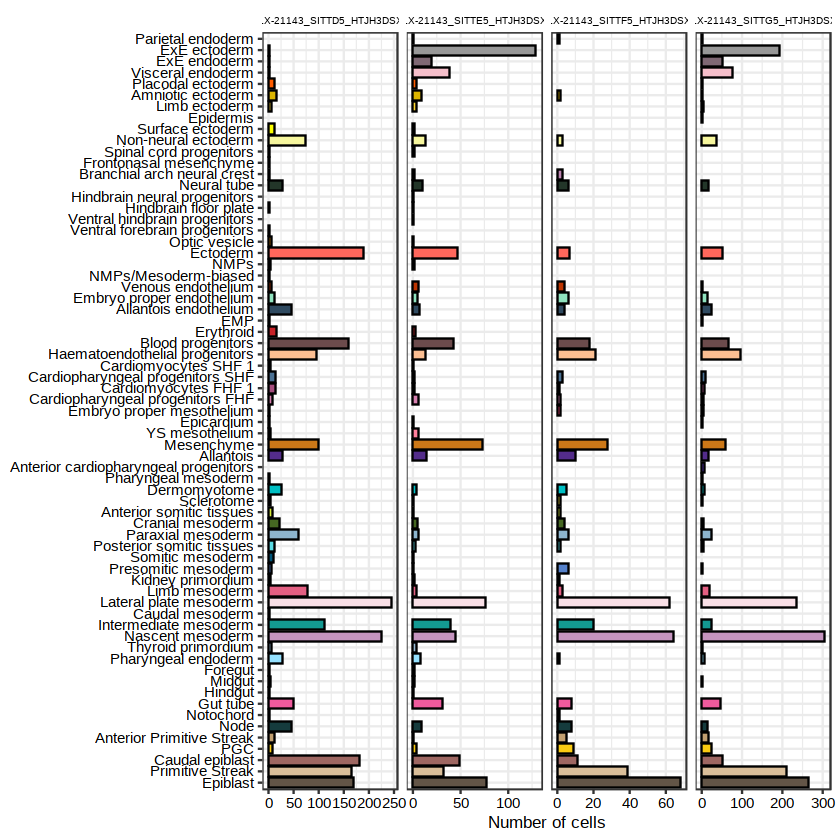

In [92]:

################################################
## Calculate cell type proportions per sample ##
################################################

to.plot <- sample_metadata %>%
  .[,N:=.N,by="sample"] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("sample","stage","celltype")] %>%
  setorder(sample)  %>% .[,sample:=factor(sample,levels=args$samples)]

# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]

for (i in unique(to.plot$stage)) {
  p <- ggplot(to.plot[stage==i], aes(x=celltype, y=N)) +
    geom_bar(aes(fill=celltype), stat="identity", color="black") +
    scale_fill_manual(values=opts$celltype.colors) +
    facet_wrap(~sample, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

print(p)
}

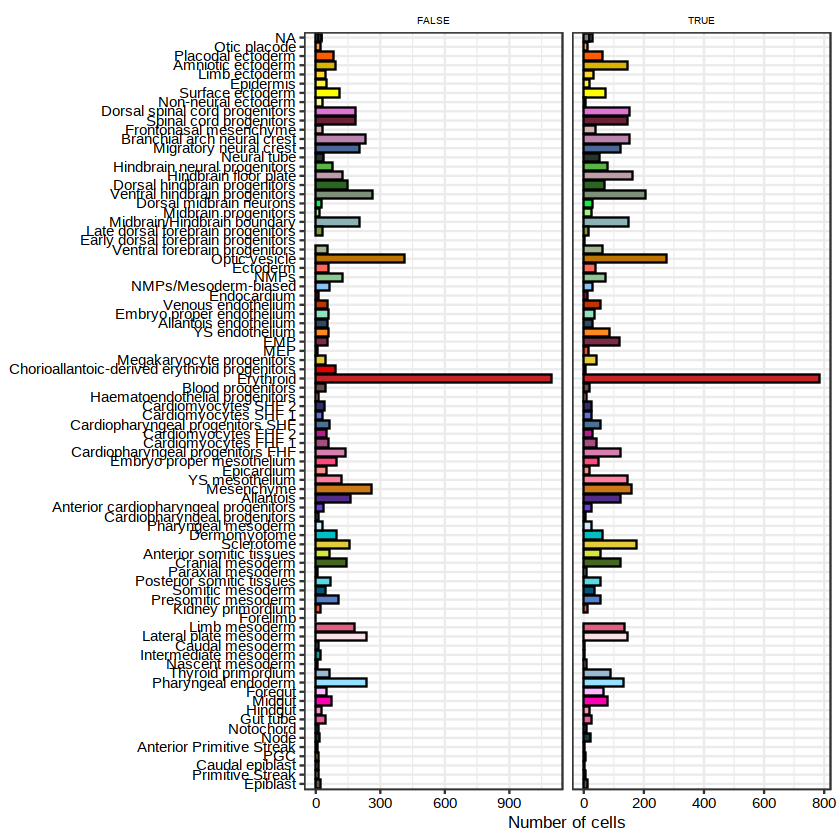

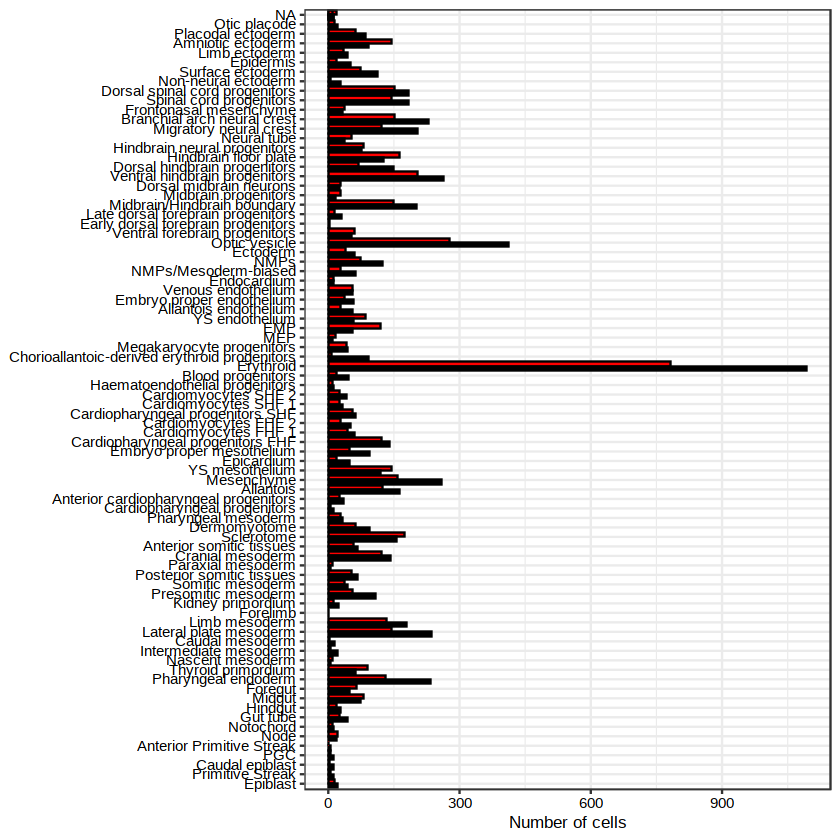

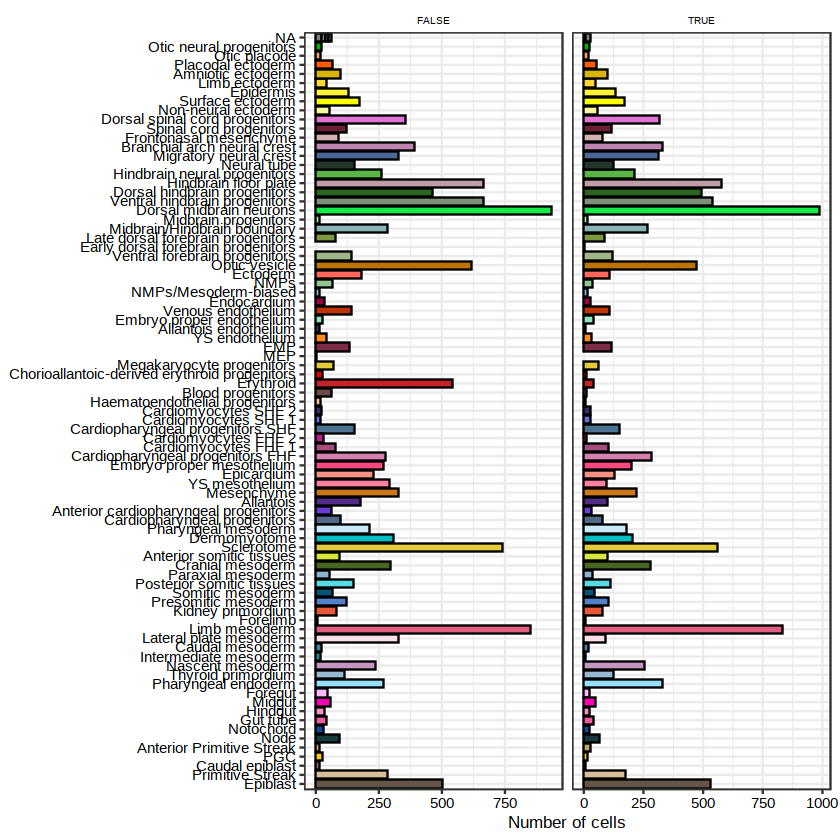

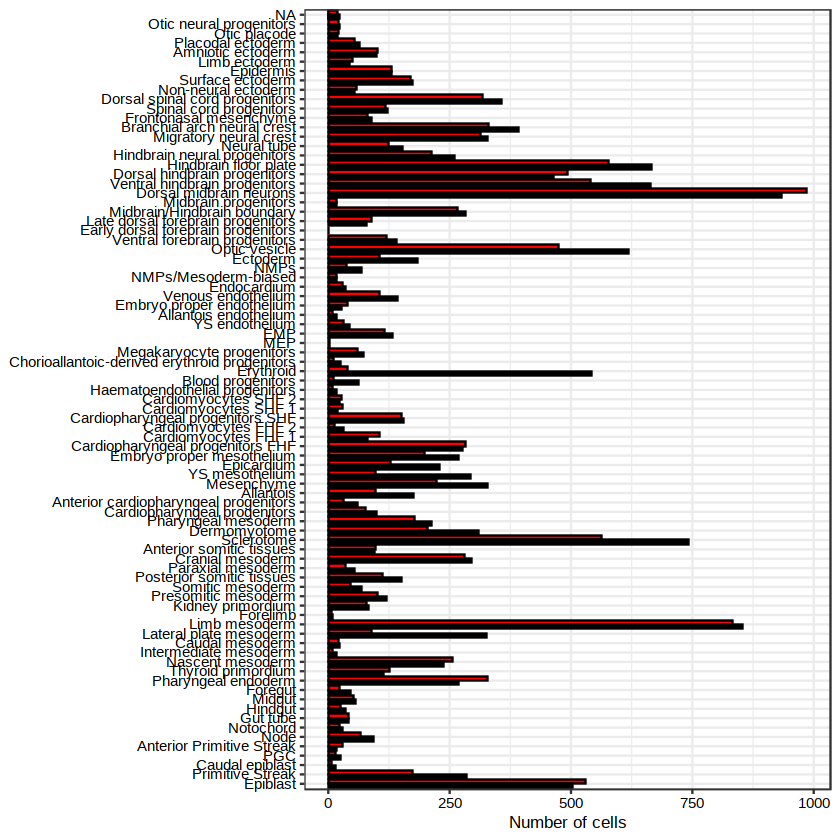

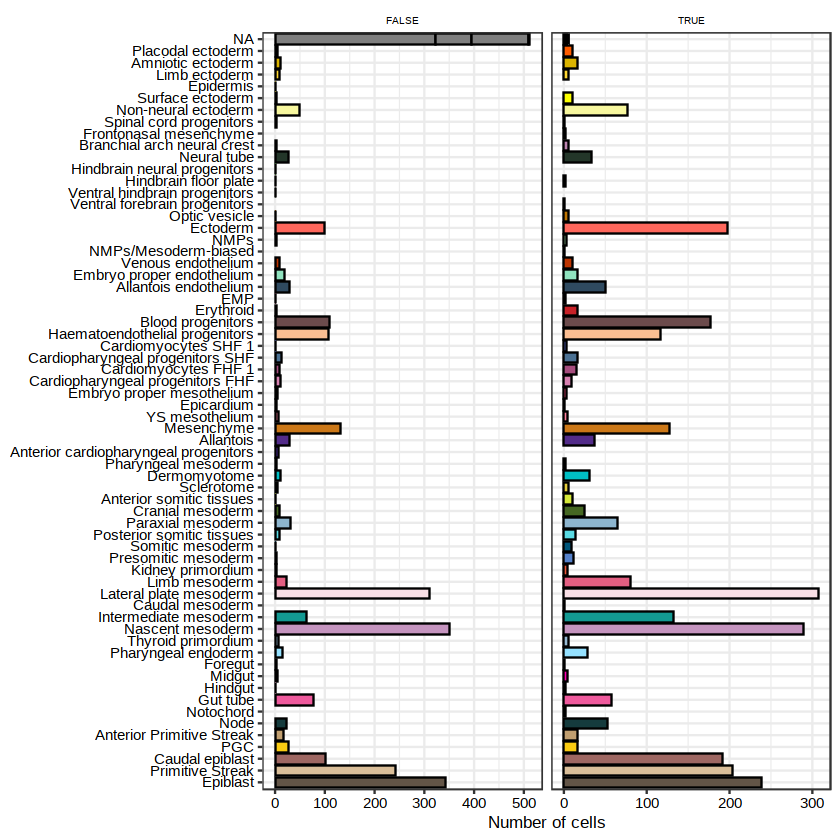

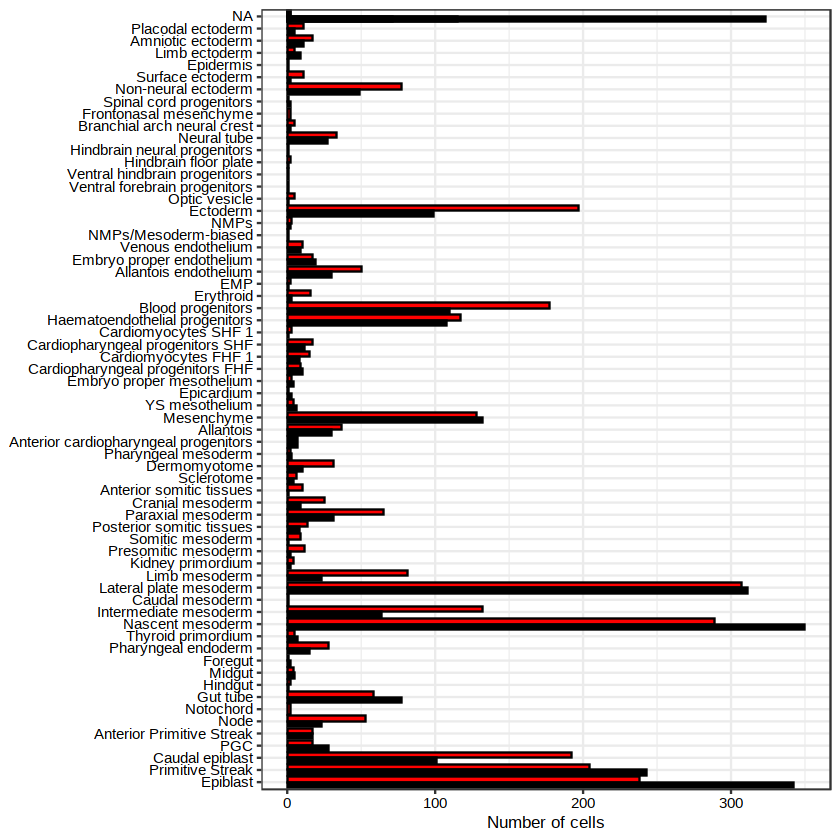

In [107]:

################################################
## Calculate cell type proportions per sample ##
################################################

to.plot <- sample_metadata %>%
  .[,N:=.N,by="tdTom"] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom","stage","celltype")] #%>%
 # setorder(sample)  #%>% .[,sample:=factor(sample,levels=args$samples)]

# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]

for (i in unique(to.plot$stage)) {
  p <- ggplot(to.plot[stage==i], aes(x=celltype, y=N)) +
    geom_bar(aes(fill=celltype), stat="identity", color="black") +
    scale_fill_manual(values=opts$celltype.colors) +
    facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

print(p)
    
      p <- ggplot(to.plot[stage==i], aes(x=celltype, y=N)) +
    geom_bar(aes(fill=tdTom), stat="identity", color="black",  position = "dodge") +
    scale_fill_manual(values=c('black', 'red')) +
  #  facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

print(p)
}

In [120]:
head(to.plot)

stage,celltype,N,celltype_proportion
<chr>,<fct>,<int>,<dbl>
E8.5,Erythroid,1877,0.041099190
E8.5,Mesenchyme,418,0.009152617
E8.5,Anterior somitic tissues,123,0.002693234
E8.5,Midbrain/Hindbrain boundary,349,0.007641778
E8.5,Spinal cord progenitors,327,0.007160061
E8.5,Branchial arch neural crest,382,0.008364353


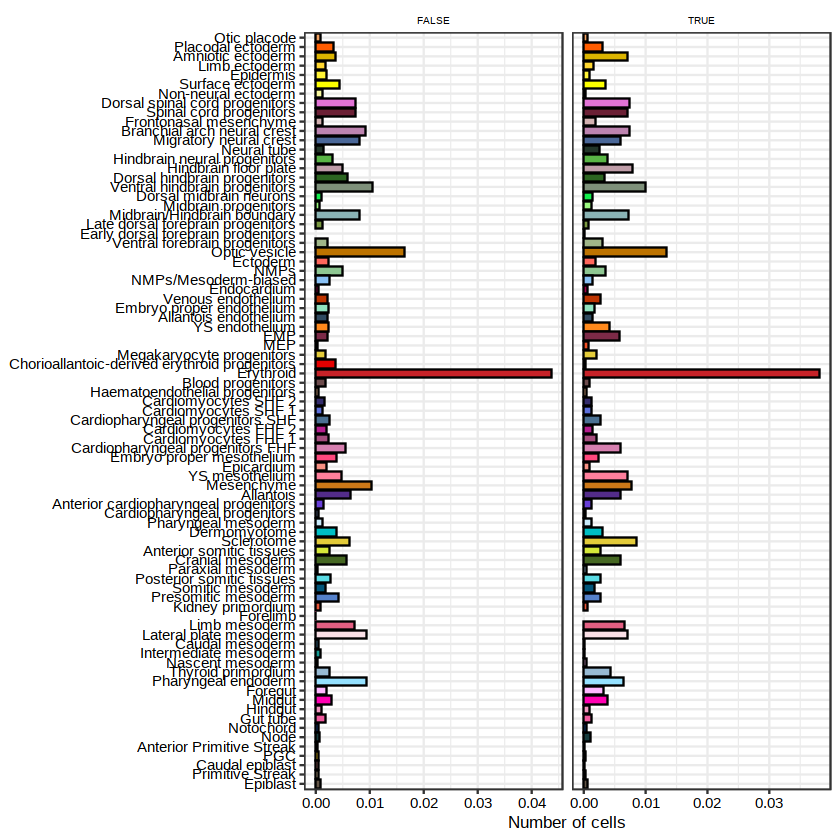

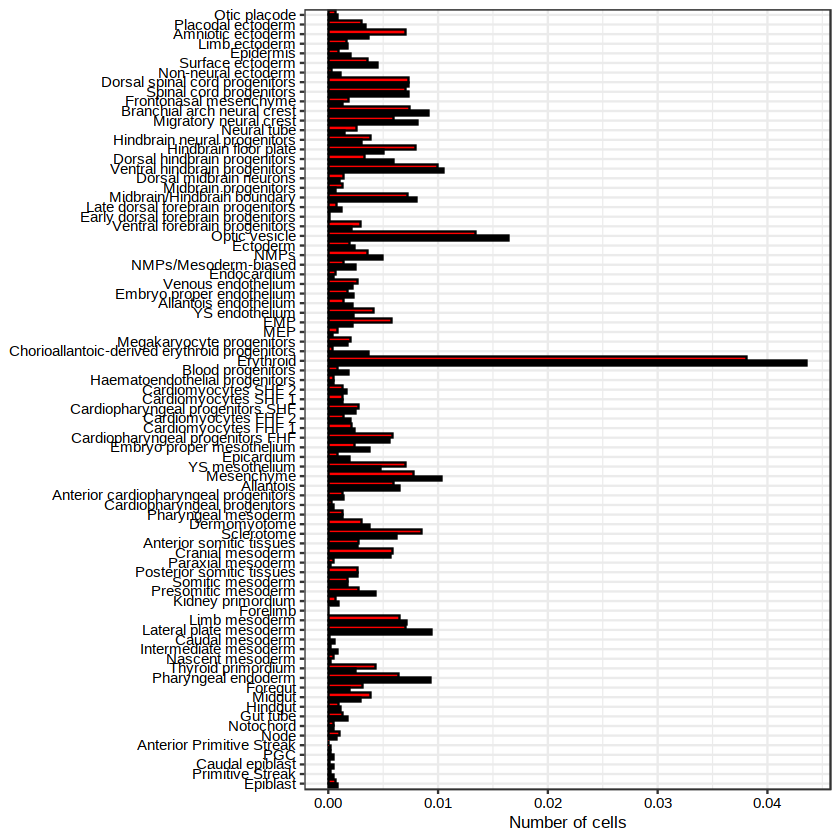

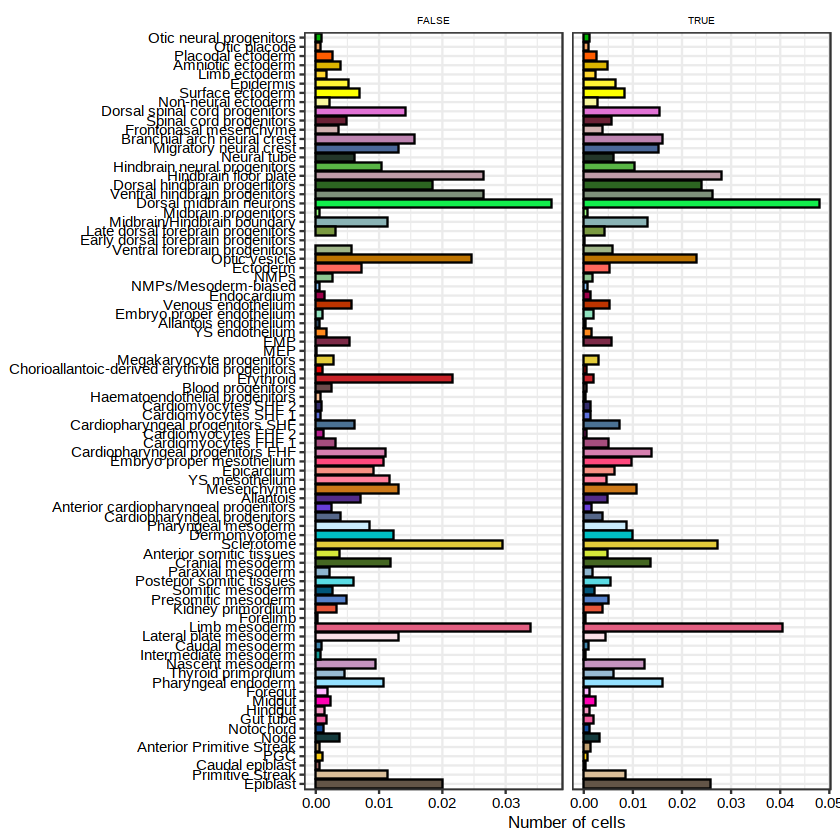

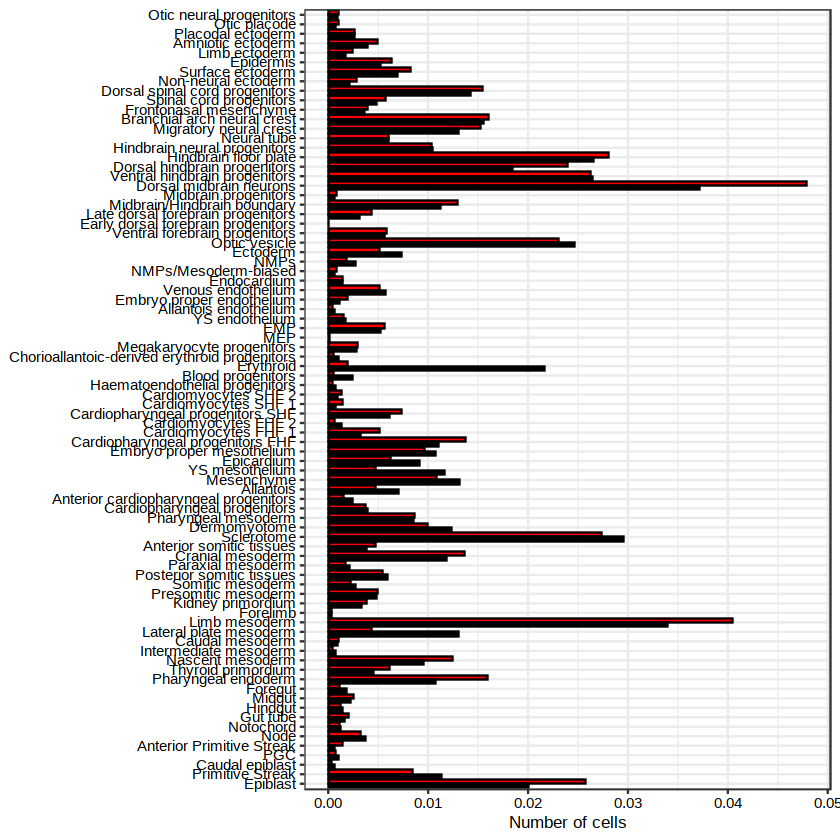

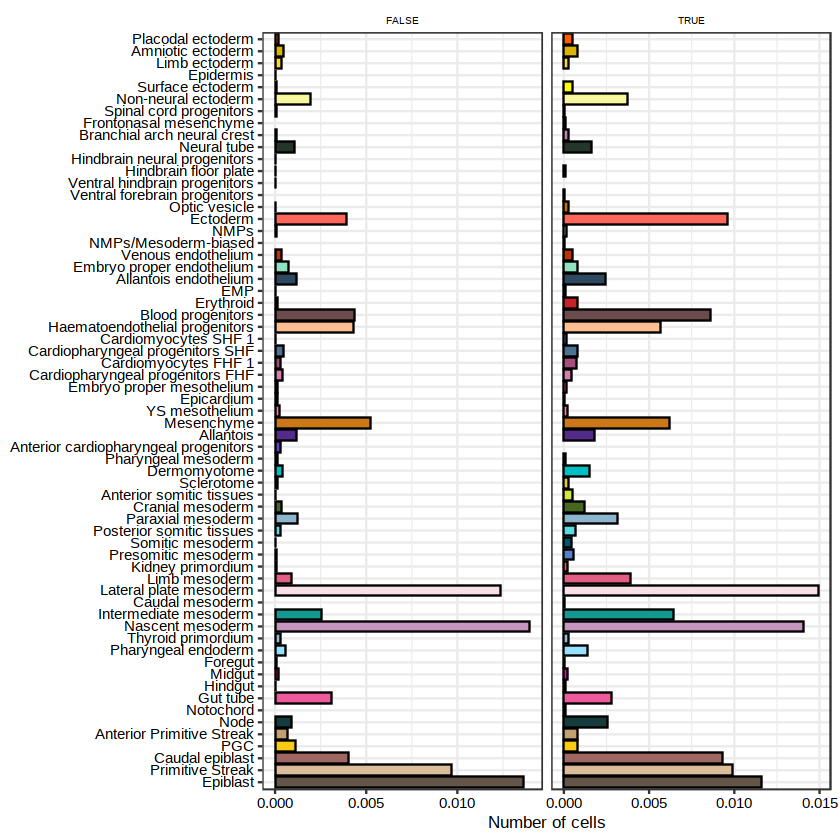

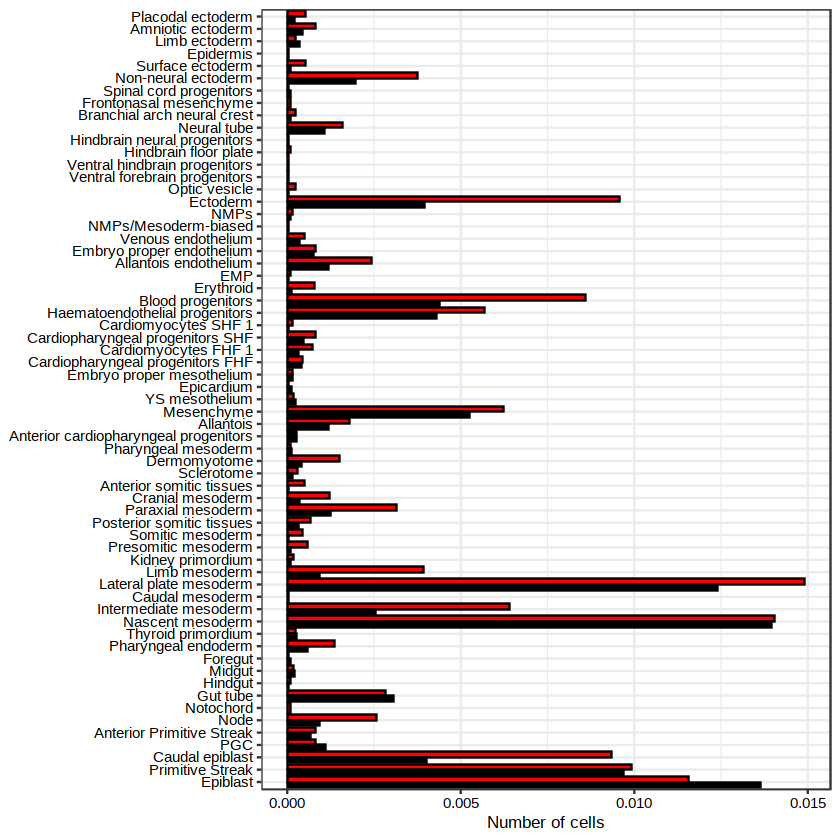

In [121]:

################################################
## Calculate cell type proportions per sample ##
################################################

to.plot <- sample_metadata %>%
  .[,N:=.N,by="tdTom"] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom","stage","celltype")] %>%
    .[!celltype%in%c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")]
 # setorder(sample)  #%>% .[,sample:=factor(sample,levels=args$samples)]

# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]

for (i in unique(to.plot$stage)) {
  p <- ggplot(to.plot[stage==i], aes(x=celltype, y=celltype_proportion)) +
    geom_bar(aes(fill=celltype), stat="identity", color="black") +
    scale_fill_manual(values=opts$celltype.colors) +
    facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

print(p)
    
          p <- ggplot(to.plot[stage==i], aes(x=celltype, y=celltype_proportion)) +
    geom_bar(aes(fill=tdTom), stat="identity", color="black",  position = "dodge") +
    scale_fill_manual(values=c('black', 'red')) +
  #  facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 
   print(p)
}

In [113]:
head(sample_metadata)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score_mnn,closest.cell_mnn,N
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<int>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCAAGATGTTCC-1,4837,53199,1.47,22.87,E8.5,TRUE,TRUE,0.18,FALSE,Erythroid,1.00,cell_33109,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCATCAGACCTA-1,4973,24165,0.95,19.26,E8.5,TRUE,TRUE,0.23,FALSE,Mesenchyme,1.00,ext_cell_41684,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACAATGTTGC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAACAATGTTGC-1,5585,34341,0.22,26.76,E8.5,TRUE,TRUE,0.22,FALSE,Anterior somitic tissues,0.80,ext_cell_66265,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAACACACCAGC-1,5016,41496,1.66,25.01,E8.5,TRUE,TRUE,0.11,FALSE,Erythroid,1.00,cell_33764,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTGATAGTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAAGTGATAGTA-1,4308,44249,0.60,24.26,E8.5,TRUE,TRUE,0.10,FALSE,Erythroid,1.00,cell_71086,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTTAAGACA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAAGTTAAGACA-1,3826,17237,1.42,28.43,E8.5,TRUE,TRUE,0.12,FALSE,Midbrain/Hindbrain boundary,0.36,ext_cell_188155,45670


In [117]:
head(to.plot)

stage,celltype,N,celltype_proportion
<chr>,<fct>,<int>,<dbl>
E8.5,Erythroid,1877,0.041099190
E8.5,Mesenchyme,418,0.009152617
E8.5,Anterior somitic tissues,123,0.002693234
E8.5,Midbrain/Hindbrain boundary,349,0.007641778
E8.5,Spinal cord progenitors,327,0.007160061
E8.5,Branchial arch neural crest,382,0.008364353


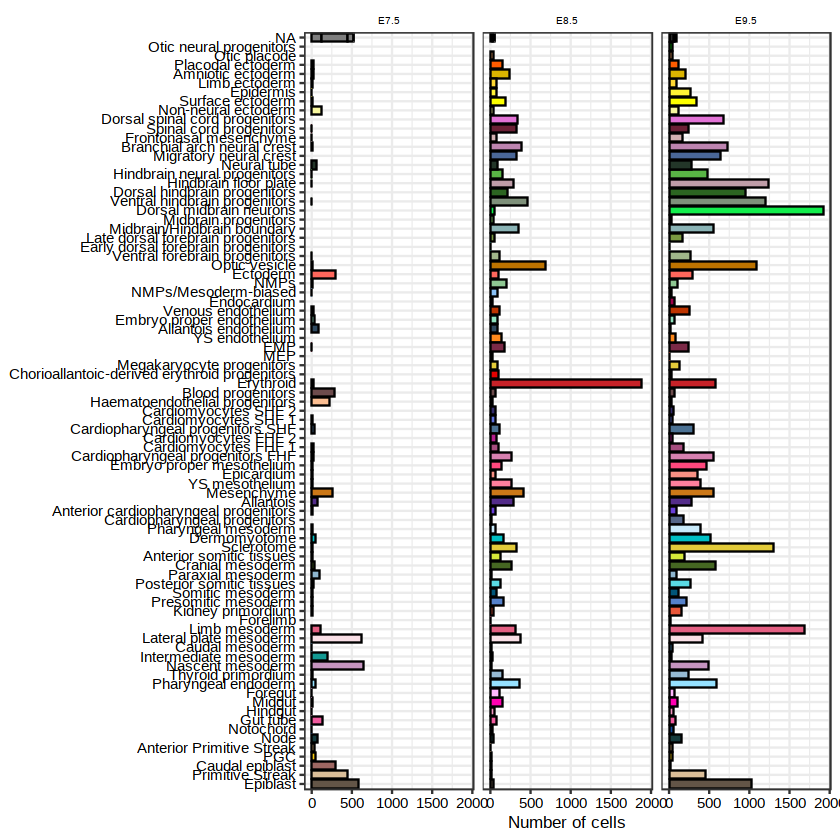

In [118]:
# All samples
to.plot <- sample_metadata %>%
  .[,N:=.N] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("stage","celltype")]
  
# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]
  
  p <- ggplot(to.plot, aes(x=celltype, y=N)) +
    geom_bar(aes(fill=celltype), stat="identity", color="black") +
    scale_fill_manual(values=opts$celltype.colors) +
    facet_wrap(~stage) + 
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    )
p

In [119]:
head(sample_metadata)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score_mnn,closest.cell_mnn,N
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<int>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCAAGATGTTCC-1,4837,53199,1.47,22.87,E8.5,TRUE,TRUE,0.18,FALSE,Erythroid,1.00,cell_33109,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCATCAGACCTA-1,4973,24165,0.95,19.26,E8.5,TRUE,TRUE,0.23,FALSE,Mesenchyme,1.00,ext_cell_41684,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACAATGTTGC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAACAATGTTGC-1,5585,34341,0.22,26.76,E8.5,TRUE,TRUE,0.22,FALSE,Anterior somitic tissues,0.80,ext_cell_66265,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAACACACCAGC-1,5016,41496,1.66,25.01,E8.5,TRUE,TRUE,0.11,FALSE,Erythroid,1.00,cell_33764,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTGATAGTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAAGTGATAGTA-1,4308,44249,0.60,24.26,E8.5,TRUE,TRUE,0.10,FALSE,Erythroid,1.00,cell_71086,45670
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTTAAGACA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACGAAGTTAAGACA-1,3826,17237,1.42,28.43,E8.5,TRUE,TRUE,0.12,FALSE,Midbrain/Hindbrain boundary,0.36,ext_cell_188155,45670


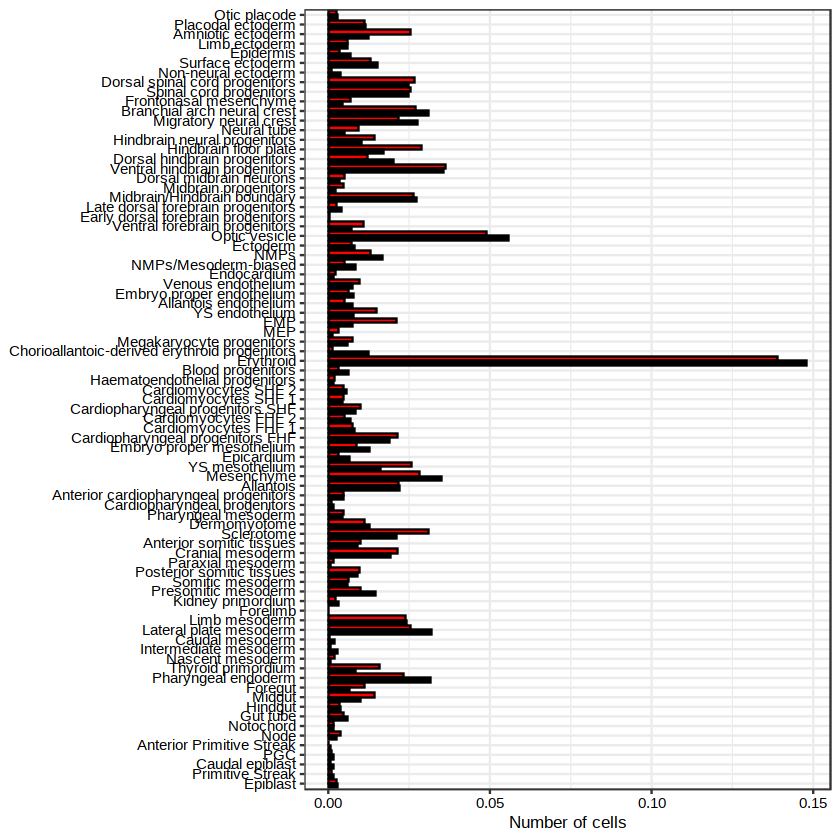

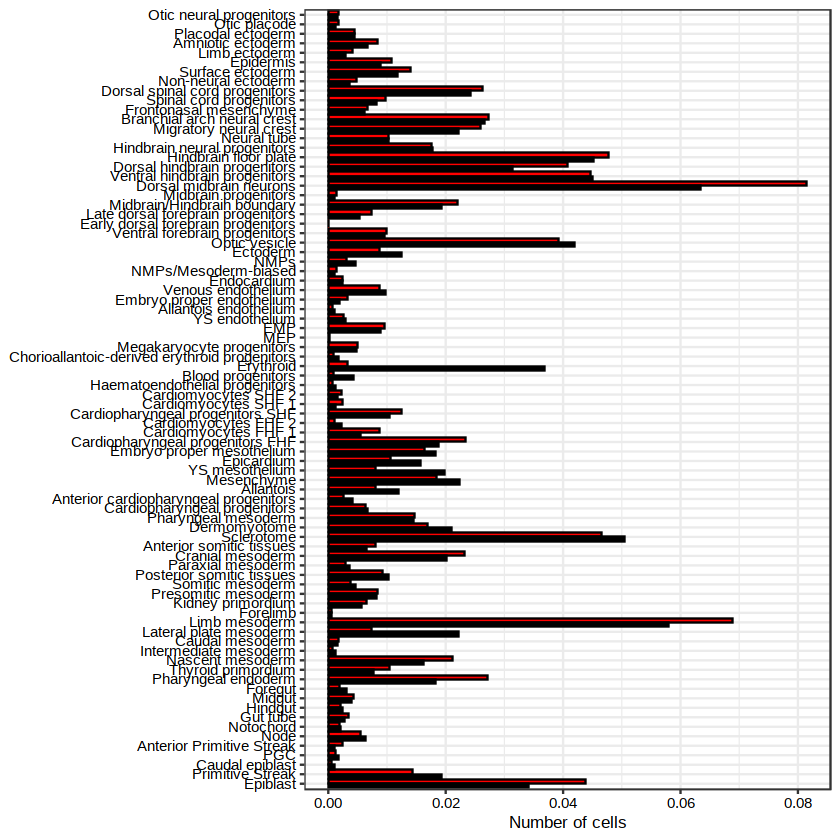

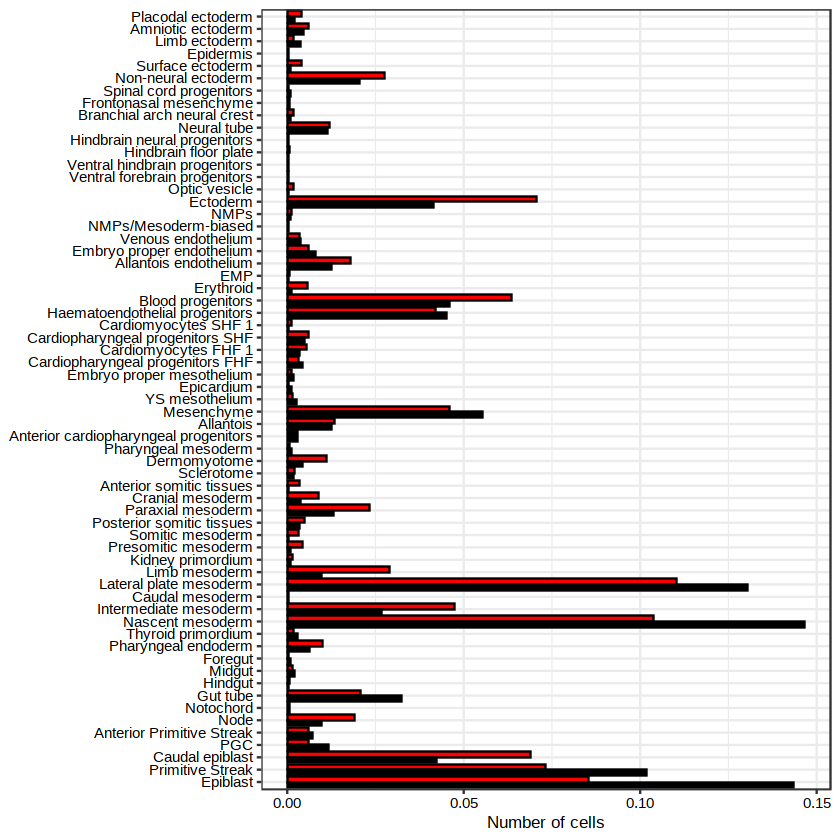

In [140]:
################################################

to.plot <- sample_metadata %>%
    .[!celltype%in%c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")] %>%
  .[,N:=.N,by=c("tdTom","stage")] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom","stage","celltype")]
 # setorder(sample)  #%>% .[,sample:=factor(sample,levels=args$samples)]

# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]

for (i in unique(to.plot$stage)) {
p <- ggplot(to.plot[stage==i], aes(x=celltype, y=celltype_proportion)) +
    geom_bar(aes(fill=tdTom), stat="identity", color="black",  position = "dodge") +
    scale_fill_manual(values=c('black', 'red')) +
  #  facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 
   print(p)
}

In [141]:
sum(to.plot$celltype_proportion)

[1] 6

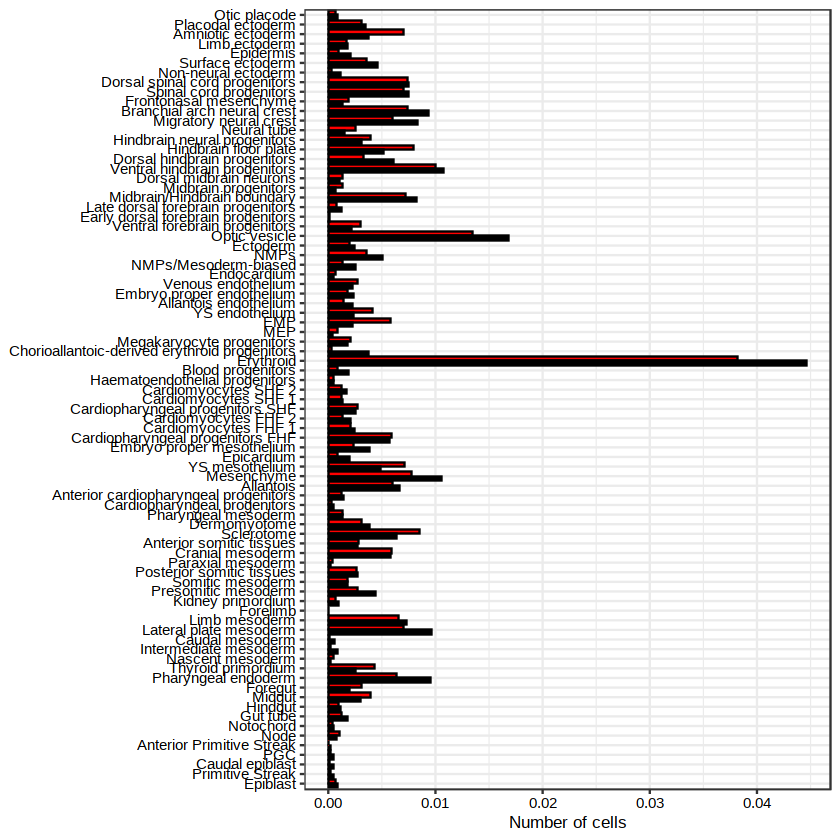

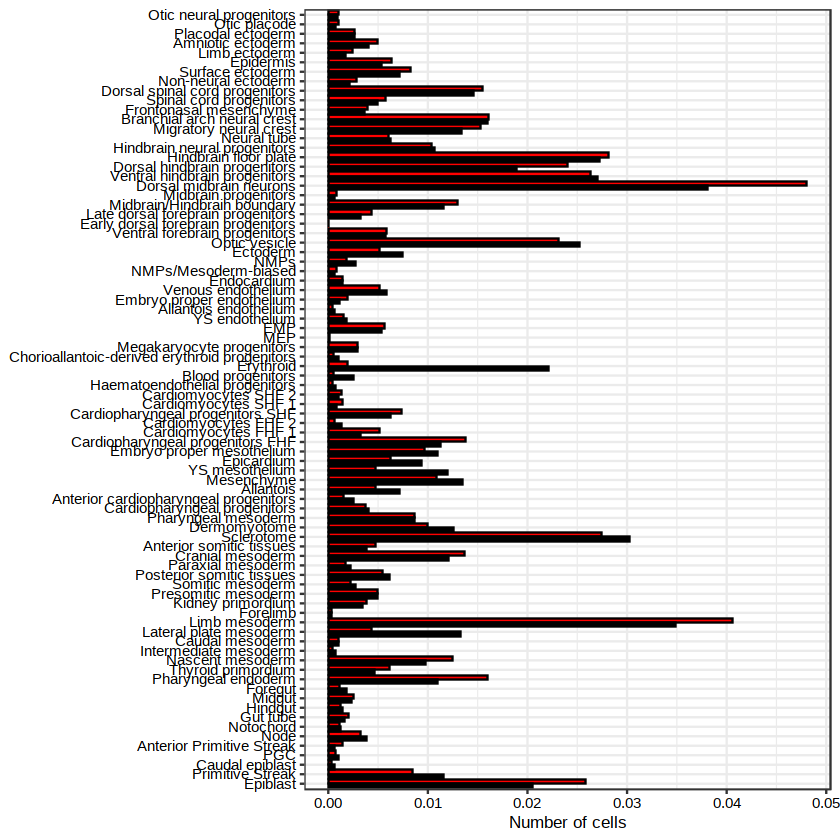

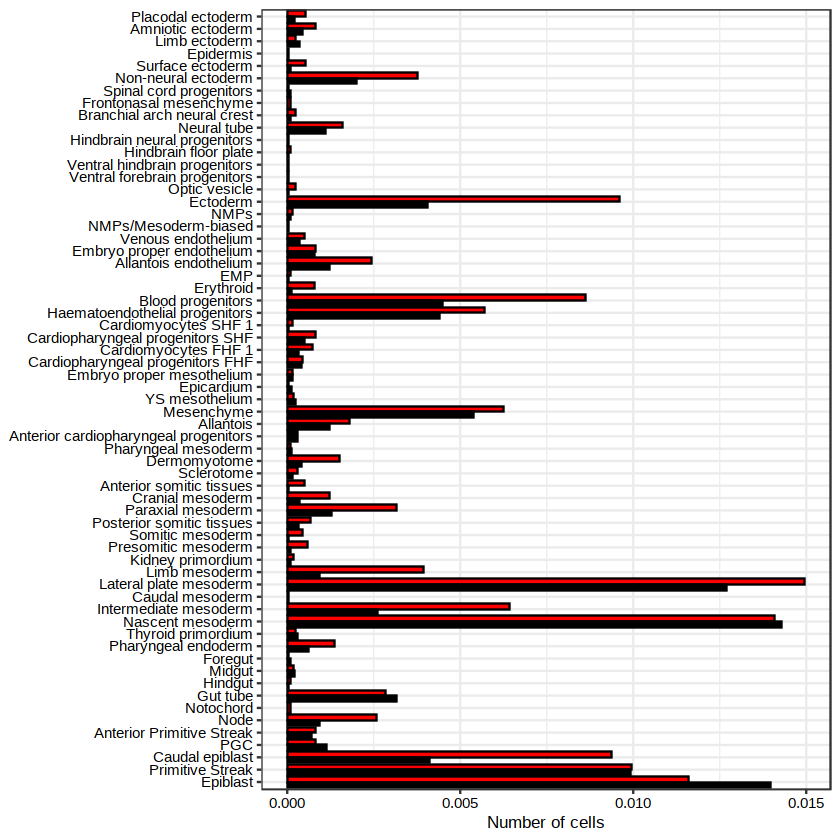

In [137]:
################################################

to.plot <- sample_metadata %>%
    .[!celltype%in%c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")] %>%
  .[,N:=.N,by=c("tdTom")] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom","stage","celltype")] 
 # setorder(sample)  #%>% .[,sample:=factor(sample,levels=args$samples)]

# Define colours and cell type order
opts$celltype.colors <- opts$celltype.colors[names(opts$celltype.colors) %in% unique(to.plot$celltype)]
to.plot[,celltype:=factor(celltype, levels=names(opts$celltype.colors))]

for (i in unique(to.plot$stage)) {
p <- ggplot(to.plot[stage==i], aes(x=celltype, y=celltype_proportion)) +
    geom_bar(aes(fill=tdTom), stat="identity", color="black",  position = "dodge") +
    scale_fill_manual(values=c('black', 'red')) +
  #  facet_wrap(~tdTom, nrow=1, scales="free_x") +
    coord_flip() +
    labs(y="Number of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 
   print(p)
}

In [138]:
sum(to.plot$celltype_proportion)

[1] 2

In [153]:
colnames(sample_metadata)

[1] "cell"                      "sample"                   
 [3] "barcode"                   "nFeature_RNA"             
 [5] "nCount_RNA"                "mitochondrial_percent_RNA"
 [7] "ribosomal_percent_RNA"     "stage"                    
 [9] "tdTom"                     "pass_rnaQC"               
[11] "doublet_score"             "doublet_call"             
[13] "celltype.mapped_mnn"       "celltype.score_mnn"       
[15] "closest.cell_mnn"

In [ ]:
############################
## PCA + Batch correction ##
############################

 if (length(args$batch_correction)>0) {
   print(sprintf("Applying MNN batch correction for variable: %s", args$batch_correction))
   pca <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[args$batch_correction]], d = args$npcs)
   pca.corrected <- reducedMNN(pca)$corrected
   colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
   reducedDim(sce_filt, "PCA") <- pca.corrected
 } else {
   
   sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  
 }

In [ ]:
 if (length(args$batch_correction)>0) {
     meta = colData(sce_filt)
#get order: oldest to youngest; most cells to least cells
order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
order_df$stage = factor(order_df$stage, 
                        levels = rev(c(
                                    "E9.5",
                                    "E8.5", 
                                    "E7.5"
                                      )))
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)

all_correct = doBatchCorrect(counts = logcounts(sce)[rownames(sce) %in% hvgs,], 
                             timepoints = meta$stage, 
                             samples = meta$sample, 
                             timepoint_order = order_df$stage, 
                             sample_order = order_df$sample, 
                             npc = args$npcs)

In [226]:
#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))


args = list()
## START TEST ##
args$samples <- opts$samples
args$sce <- io$rna.sce
args$metadata <- io$metadata
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$features <- 3000
args$npcs <- 50
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA")
args$batch_correction <- 'TRUE'
args$remove_ExE_cells <- FALSE
args$min_dist = 0.5
args$n_neighbors = 30
#args$outdir <- paste0(io$basedir,"/results/rna/dimensionality_reduction/test")
## END TEST ##

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [227]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$samples]


if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")]
}


In [228]:
###################
## Sanity checks ##
###################

stopifnot(args$colour_by %in% colnames(sample_metadata))
# stopifnot(unique(sample_metadata$celltype.mapped) %in% names(opts$celltype.colors))

 if (length(args$batch_correction)=='TRUE') {
     library(batchelor)
   }


 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }


In [229]:
###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [230]:
#######################
## Feature selection ##
#######################

 if (length(args$batch_correction)=='TRUE') {
   decomp <- modelGeneVar(sce, block=colData(sce)$sample)
 } else {
     print('no batch corr')
   decomp <- modelGeneVar(sce)
 }
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

[1] "no batch corr"


In [213]:
############################
## Regress out covariates ##
############################

 if (length(args$vars_to_regress)>0) {
   print(sprintf("Regressing out variables: %s", paste(args$vars_to_regress,collapse=" ")))
   logcounts(sce_filt) <- RegressOutMatrix(
     mtx = logcounts(sce_filt), 
     covariates = colData(sce_filt)[,args$vars_to_regress,drop=F]
   )
 }


In [214]:
source("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code/mapping/run/mnn/mapping_functions.R")

In [215]:
sce_filt

class: SingleCellExperiment 
dim: 3000 45670 
metadata(0):
assays(2): counts logcounts
rownames(3000): Col3a1 Igfbp2 ... Oat 5330434G04Rik
rowData names(0):
colnames(45670): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
colData names(14): sample barcode ... celltype.score_mnn
  closest.cell_mnn
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [216]:

############################
## PCA + Batch correction ##
############################

 if (length(args$batch_correction)=='TRUE') {
     meta = colData(sce_filt)
    #get order: oldest to youngest; most cells to least cells
    order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
    order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
    order_df$stage = factor(order_df$stage, 
                            levels = rev(c(
                                        "E9.5",
                                        "E8.5", 
                                        "E7.5"
                                          )))
    order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
    order_df$stage = as.character(order_df$stage)

    all_correct = doBatchCorrect(counts = logcounts(sce_filt), 
                                 timepoints = meta$stage, 
                                 samples = meta$sample, 
                                 timepoint_order = order_df$stage, 
                                 sample_order = order_df$sample, 
                                 npc = args$npcs)
                         
   colnames(all_correct) <- paste0("PC",1:ncol(all_correct))
   reducedDim(sce_filt, "PCA") <- all_correct
 } else {
   
   sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  
 }


In [217]:
sce_filt

class: SingleCellExperiment 
dim: 3000 45670 
metadata(0):
assays(2): counts logcounts
rownames(3000): Col3a1 Igfbp2 ... Oat 5330434G04Rik
rowData names(0):
colnames(45670): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
colData names(14): sample barcode ... celltype.score_mnn
  closest.cell_mnn
reducedDimNames(1): PCA
mainExpName: RNA
altExpNames(0):

In [218]:
##########
## UMAP ##
##########

# Run
set.seed(args$seed)
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

##########
## Plot ##
##########
to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

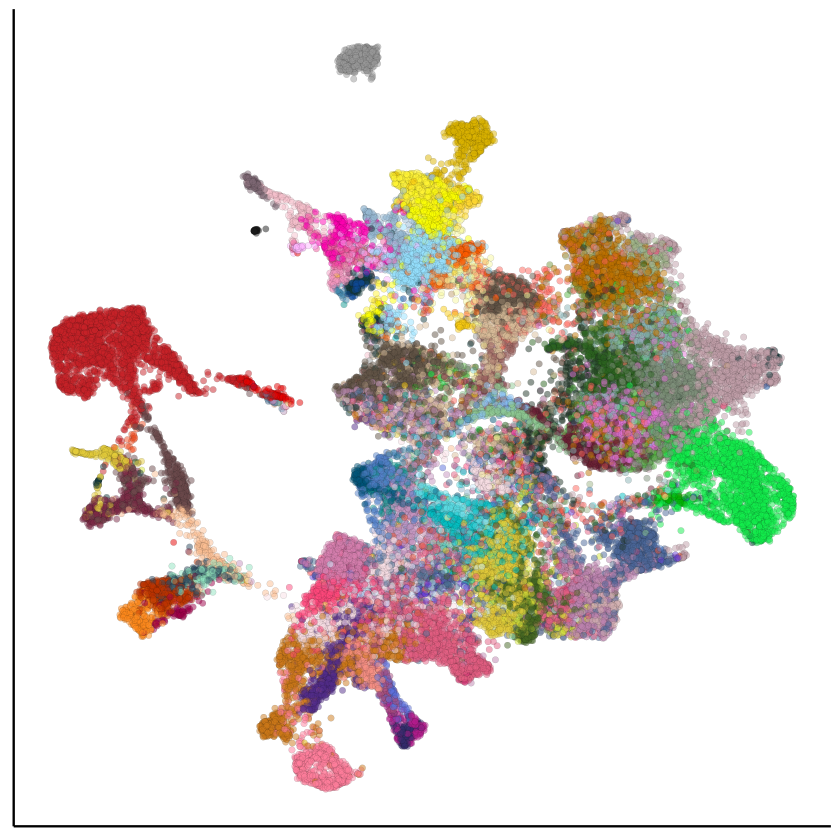

In [219]:
ggplot(to.plot, aes_string(x="V1", y="V2", fill='celltype.mapped_mnn')) +
    geom_point(size=1.5, shape=21, stroke=0.05, alpha=0.5) +
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) + scale_fill_manual(values=opts$celltype.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )

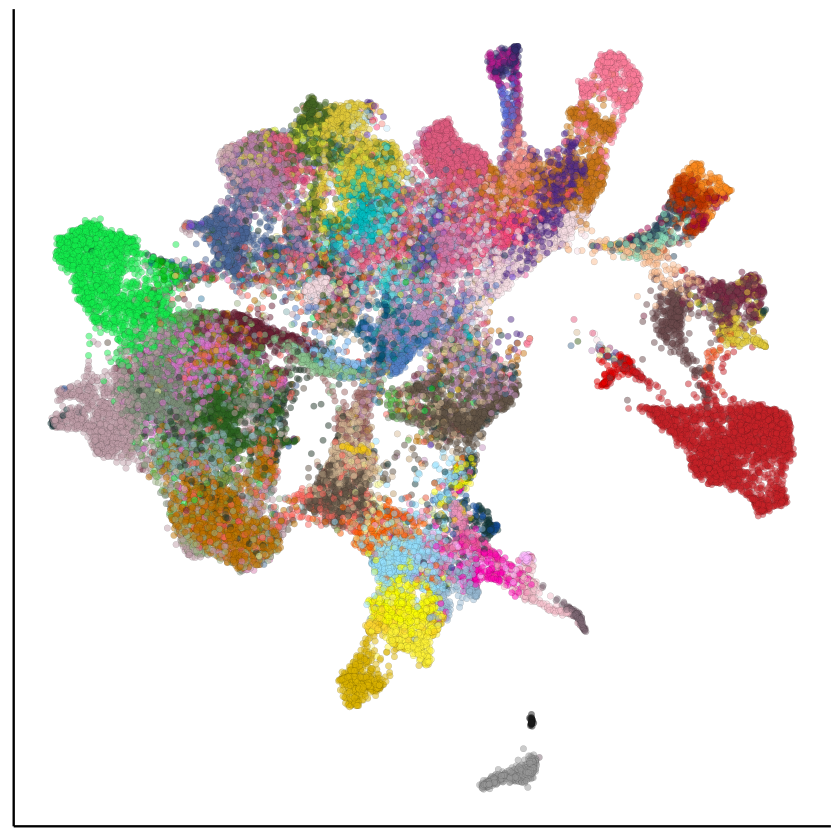

In [206]:
# pcs = 30, nfeatures = 1000
ggplot(to.plot, aes_string(x="V1", y="V2", fill='celltype.mapped_mnn')) +
    geom_point(size=1.5, shape=21, stroke=0.05, alpha=0.5) +
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) + scale_fill_manual(values=opts$celltype.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )

In [223]:
args$batch_correction <- 'TRUE'
if(args$batch_correction == 'TRUE'){ 
 print('yes')}

[1] "yes"


In [222]:
args$batch_correction

[1] "TRUE"

In [224]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))

######################
## Define arguments ##
######################

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

## START TEST ##
args = list()
args$samples <- opts$samples
args$sce <- io$rna.sce
args$metadata <- io$metadata
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$features <- 2500
args$npcs <- 50
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA")
args$batch_correction <- 'TRUE'
args$remove_ExE_cells <- FALSE
args$min_dist = 0.5
args$n_neighbors = 30
# args$outdir <- paste0(io$basedir,"/results/rna/dimensionality_reduction/test")
## END TEST ##

# if (isTRUE(args$test)) print("Test mode activated...")

##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$samples]


if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")]
}

###################
## Sanity checks ##
###################

stopifnot(args$colour_by %in% colnames(sample_metadata))
# stopifnot(unique(sample_metadata$celltype.mapped) %in% names(opts$celltype.colors))

 if (args$batch_correction=='TRUE') {
     source(here::here("mapping/run/mnn/mapping_functions.R"))
     library(batchelor)
   }

 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }


###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

#######################
## Feature selection ##
#######################

 if (args$batch_correction=='TRUE') {
   decomp <- modelGeneVar(sce, block=colData(sce)$sample)
 } else {
     print('no batch corr')
   decomp <- modelGeneVar(sce)
 }
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

############################
## Regress out covariates ##
############################

 if (length(args$vars_to_regress)>0) {
   print(sprintf("Regressing out variables: %s", paste(args$vars_to_regress,collapse=" ")))
   logcounts(sce_filt) <- RegressOutMatrix(
     mtx = logcounts(sce_filt), 
     covariates = colData(sce_filt)[,args$vars_to_regress,drop=F]
   )
 }

############################
## PCA + Batch correction ##
############################

 if (args$batch_correction=='TRUE') {
     meta = colData(sce_filt)
    #get order: oldest to youngest; most cells to least cells
    order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
    order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
    order_df$stage = factor(order_df$stage, 
                            levels = rev(c(
                                        "E9.5",
                                        "E8.5", 
                                        "E7.5"
                                          )))
    order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
    order_df$stage = as.character(order_df$stage)

    all_correct = doBatchCorrect(counts = logcounts(sce_filt), 
                                 timepoints = meta$stage, 
                                 samples = meta$sample, 
                                 timepoint_order = order_df$stage, 
                                 sample_order = order_df$sample, 
                                 npc = args$npcs)
                         
   colnames(all_correct) <- paste0("PC",1:ncol(all_correct))
   reducedDim(sce_filt, "PCA") <- all_correct
 } else {
   
   sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  
 }



##########
## UMAP ##
##########

# Run
set.seed(args$seed)
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

# Save UMAP coordinates


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



ERROR: Error in fwrite(umap.dt, sprintf("%s/umap_features%d_pcs%d_neigh%d_dist%s.txt.gz", : is.character(file) && length(file) == 1L && !is.na(file) is not TRUE


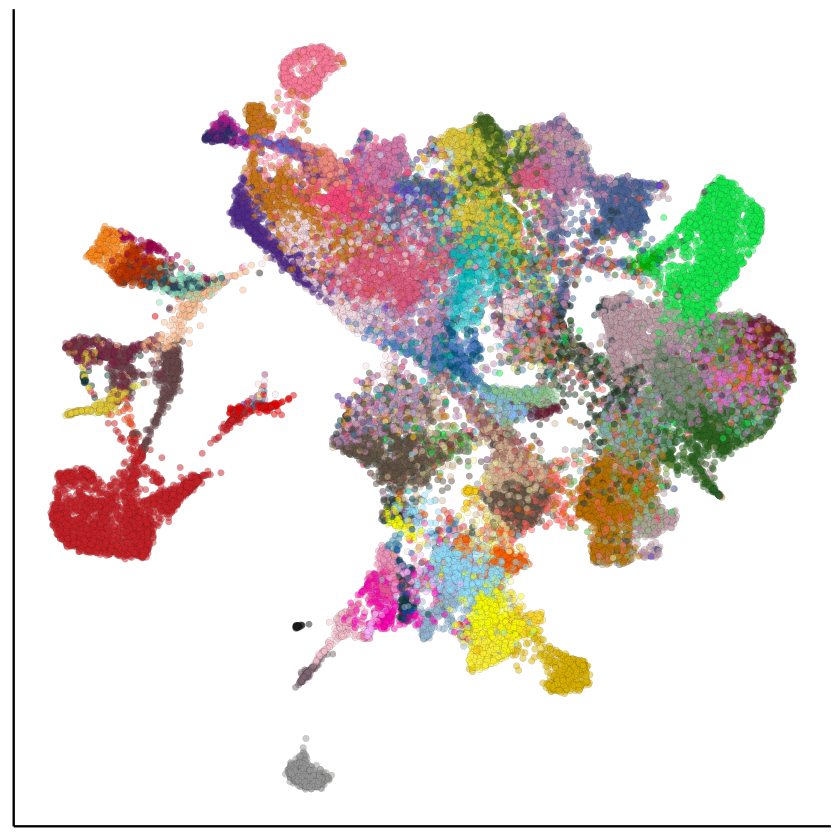

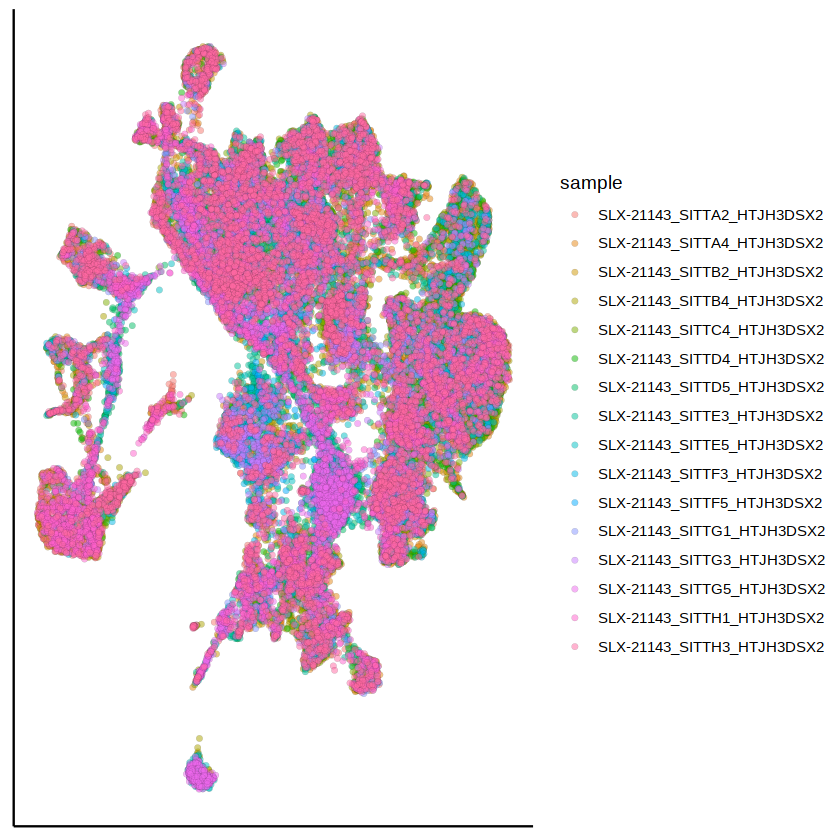

In [225]:

##########
## Plot ##
##########
to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")
    
for (i in args$colour_by) {



  p <- ggplot(to.plot, aes_string(x="V1", y="V2", fill=i)) +
    geom_point(size=1.5, shape=21, stroke=0.05, alpha=0.5) +
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )

  if (grepl("celltype.mapped",i)) {
    p <- p + scale_fill_manual(values=opts$celltype.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )
  }
  
  if (grepl("stage",i)) {
    p <- p + scale_fill_manual(values=opts$stage.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )
  }
print(p)
}



In [2]:
suppressPackageStartupMessages(library(Seurat))
library(dplyr)
library(data.table)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [6]:
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T/code



In [7]:
args = list()
args$samples = paste0('sample_', c(1,2, 5:10))
args$inputdir = '/rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T/data'
opts = list()
opts$trim.barcode <- FALSE
opts$sample_cell_separator <- "#"

In [38]:
cell.info = list()
count_mtx = list()
for (i in args$samples) {
  print(i)
    

  # Load gene metadata
  # gene.loc <- sprintf("%s/%s/genes.tsv.gz",args$inputdir,i)
  # gene.info[[i]] <- fread(gene.loc, header=F) %>%
  #   setnames(c("ens_id","symbol")) %>%
  #   .[,idx:=1:.N]
  # dim(gene.info[[i]])
  
  # Load cell metadata
  barcode.loc <- sprintf("%s/%s/outs/filtered_feature_bc_matrix/barcodes.tsv.gz",args$inputdir,i)
  cell.info[[i]] <- fread(barcode.loc, header=F) %>%
    setnames("barcode") %>%
    .[,barcode:=ifelse(rep(opts$trim.barcode,.N),gsub("-1","",barcode),barcode)] %>%
    .[,c("sample","cell"):=list(i,sprintf("%s%s%s",i,opts$sample_cell_separator,barcode))]
  dim(cell.info[[i]])
  
  # Load matrix  
  count_mtx[[i]] <- Read10X(sprintf("%s/%s/outs/filtered_feature_bc_matrix/",args$inputdir,i))
}

[1] "sample_1"
[1] "sample_2"
[1] "sample_5"
[1] "sample_6"
[1] "sample_7"
[1] "sample_8"
[1] "sample_9"
[1] "sample_10"


In [10]:
test <- Read10X(sprintf("%s/%s/outs/filtered_feature_bc_matrix/",args$inputdir,'sample_2'))


In [ ]:

#######################
## Keep common genes ##
#######################

genes <- Reduce("intersect",lapply(count_mtx,rownames))
for (i in 1:length(count_mtx)) {
  count_mtx[[i]] <- count_mtx[[i]][genes,]
}

stopifnot(length(unique(lapply(count_mtx,nrow)))==1)
stopifnot(length(unique(lapply(count_mtx,rownames)))==1)

#################
## Concatenate ##
#################

# Concatenate cell metadata
cell.info <- rbindlist(cell.info)
rownames(cell.info) <- cell.info$cell

# Concatenate matrices
count_mtx <- do.call("cbind",count_mtx)
colnames(count_mtx) <- cell.info$cell

##################
## Filter genes ##
##################

# Keep protein-coding genes
# if (!is.null(opts$subset.proteincoding)){
#     genes <- fread(opts$subset.proteincoding)[,ens_id]
#     genes <- genes[genes %in% mouse.genes]
#     mouse.genes <- mouse.genes[mouse.genes %in% genes]
#     count_mtx <- count_mtx[mouse.genes,]
# }

# Remove duplicated genes
count_mtx <- count_mtx[!duplicated(rownames(count_mtx)),]

# Sanity checks
stopifnot(sum(duplicated(rownames(count_mtx)))==0)
stopifnot(sum(duplicated(colnames(count_mtx)))==0)

##########################
## Create Seurat object ##
##########################

cell.info.to.seurat <- cell.info[cell%in%colnames(count_mtx)] %>% setkey(cell) %>% .[colnames(count_mtx)] %>% as.data.frame
rownames(cell.info.to.seurat) <- cell.info.to.seurat$cell
stopifnot(rownames(cell.info.to.seurat)==colnames(count_mtx))
stopifnot(sum(is.na(rownames(cell.info.to.seurat$cell)))==0)

seurat <- CreateSeuratObject(count_mtx, meta.data = cell.info.to.seurat)

head(seurat@meta.data)

# Add mitochondrial percenatge
seurat[["mitochondrial_percent_RNA"]] <- PercentageFeatureSet(seurat, pattern = "^mt-") %>% round(2)

# Add ribosomal RNA content
ribo.genes <- grep(pattern = "^Rp[l|s]", x = rownames(seurat), value = TRUE)
seurat[["ribosomal_percent_RNA"]] <- PercentageFeatureSet(seurat, features = ribo.genes) %>% round(2)

#####################
## Create metadata ##
#####################

metadata <- seurat@meta.data %>% as.data.table %>% .[,orig.ident:=NULL] %>%
  .[,c("cell","barcode","sample","nFeature_RNA","nCount_RNA","mitochondrial_percent_RNA","ribosomal_percent_RNA")]

stages = data.frame(sample = names(opts$sample2stage), stage = opts$sample2stage)
tdTom = data.frame(sample = names(opts$sample2stage), tdTom = opts$sample2tomato)

add_meta = merge(stages, tdTom, by= 'sample')
metadata = merge(metadata, add_meta, by='sample')

# Add correction for tdTom based on expression # Added later so check if it doesn't mess up codes
tdtom_corr = data.table(cell = colnames(seurat), tdTom_corr = ifelse(seurat['tomato-td']@assays$RNA@counts>0, TRUE, FALSE))
metadata = metadata[,idx:=.I] %>%
    merge(tdtom_corr, by='cell', all=TRUE) %>%
    .[,tdTom_corr:=ifelse(tdTom==TRUE & !is.na(tdTom_corr), TRUE, tdTom_corr)] %>% 
    .[order(idx)] 

Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 6.4 GiB”


In [ ]:
seurat

In [ ]:
head(metadata)